# Ejemplo de análisis espacial: NDVI y cobertura vegetal en Gandoca-Manzanillo

<div style="display: flex; justify-content: flex-start;">
  <a href="https://colab.research.google.com/github/tpb708-programacionsig/2026-i/blob/main/contenidos/iv-procesamiento-datos-geoespaciales/07-ejemplo-analisis-ndvi-gandoca.ipynb">
    <img src="https://img.shields.io/badge/Abrir%20en-Colab-F9AB00?logo=googlecolab&logoColor=white" alt="Abrir en Colab" style="margin: 0;">
  </a>
</div>

## Trabajo previo

### Lecturas

Tenkanen, H., Heikinheimo, V., & Whipp, D. (2024). *Introduction to Python for Geographic Data Analysis*. CRC Press. [https://pythongis.org/](https://pythongis.org/)
\
\
Lovelace, R., Nowosad, J., & Müller, J. (2024). *Geocomputation with Python*. CRC Press. [https://py.geocompx.org/](https://py.geocompx.org/)

### Otros recursos

Documentación oficial de rasterio\
[rasterio documentation](https://rasterio.readthedocs.io/)

  - [Masking a raster using a shapefile](https://rasterio.readthedocs.io/en/stable/topics/masking-by-shapefile.html)
  - [rasterio.features.geometry_mask](https://rasterio.readthedocs.io/en/stable/api/rasterio.features.html#rasterio.features.geometry_mask)

Sistema Nacional de Áreas de Conservación (SINAC)\
[SINAC](https://www.sinac.go.cr/)

Tucker, C. J. (1979). Red and photographic infrared linear combinations for monitoring vegetation. *Remote Sensing of Environment*, 8(2), 127–150. [https://www.sciencedirect.com/science/article/abs/pii/0034425779900130](https://www.sciencedirect.com/science/article/abs/pii/0034425779900130)

Referencia de paletas de colores de matplotlib\
[Colormap reference — matplotlib documentation](https://matplotlib.org/stable/gallery/color/colormap_reference.html)

## Introducción

El **Índice de Vegetación de Diferencia Normalizada** (NDVI, por sus siglas en inglés) es uno de los índices más usados en teledetección para caracterizar la cobertura vegetal. Se calcula a partir de las bandas roja (R) e infrarroja cercana (NIR) de una imagen satelital:

$$
\text{NDVI} = \frac{\text{NIR} - \text{R}}{\text{NIR} + \text{R}}
$$

El NDVI toma valores en el rango $[-1, 1]$. Una clasificación común es:

- $\text{NDVI} < 0$: agua o superficies sin vegetación.
- $0 \le \text{NDVI} < 0.2$: suelo desnudo o vegetación muy escasa.
- $0.2 \le \text{NDVI} < 0.5$: vegetación moderada (pastizales, cultivos).
- $\text{NDVI} \ge 0.5$: vegetación densa (bosques).

Este cuaderno calcula y clasifica el NDVI a partir de una imagen satelital del **Refugio Nacional de Vida Silvestre Mixto Gandoca-Manzanillo**, un área protegida del Caribe Sur de Costa Rica que combina bosque, manglar y ecosistemas costero-marinos. El análisis consta de tres pasos:

1. Calcular el NDVI a partir de las bandas roja y NIR de toda la imagen.
2. Clasificar los valores de NDVI en categorías de cobertura sobre toda la imagen.
3. Calcular estadísticas zonales del NDVI **dentro del polígono del refugio**, y compararlas con la imagen completa.

## Carga de bibliotecas

In [1]:
# Carga de rasterio
import rasterio

# Módulo de rasterio para graficar datos raster
import rasterio.plot

# Módulo de rasterio para construir máscaras a partir de geometrías
from rasterio.features import geometry_mask

# Carga de geopandas con el alias gpd
import geopandas as gpd

# Carga de pandas con el alias pd
import pandas as pd

# Biblioteca para álgebra lineal
import numpy as np

# Carga de matplotlib y utilidades de color
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Carga de la clase WebFeatureService del módulo wfs de owslib
from owslib.wfs import WebFeatureService

# Carga de la clase BytesIO del módulo estándar io
from io import BytesIO

## Carga de datos

### Imagen satelital de Gandoca

La imagen es un recorte multibanda de la zona costera del Caribe Sur, alojada en el repositorio del curso. Se abre con `rasterio.open()`.

In [2]:
# Lectura de la imagen satelital
imagen = rasterio.open(
    'https://github.com/tpb708-programacionsig/2026-i/raw/refs/heads/main/datos/sentinel/gandoca-20240105.tif'
)

print(imagen)

<open DatasetReader name='https://github.com/tpb708-programacionsig/2026-i/raw/refs/heads/main/datos/sentinel/gandoca-20240105.tif' mode='r'>


In [3]:
# Metadatos de la imagen
imagen.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': None,
 'width': 128,
 'height': 154,
 'count': 7,
 'crs': CRS.from_wkt('PROJCRS["WGS 84 / Equal Earth Greenwich",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["Equal Earth Greenwich",METHOD["Equal Earth",ID["EPSG",1078]],PARAMETER["Longitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["False easting",0,LENGTHUNIT["metre",1],ID["EPSG",8806]],PARA

### Refugio Gandoca-Manzanillo (WFS SINAC)

El polígono del refugio se obtiene del servicio WFS del SINAC. Primero listamos las capas disponibles en el servicio.

In [4]:
# Conexión al servicio WFS del SINAC
wfs_url = 'http://geos1pne.sirefor.go.cr/wfs'
wfs_version = '1.1.0'
wfs = WebFeatureService(url=wfs_url, version=wfs_version)

# Lista de las capas disponibles en el servicio WFS
for nombre_capa in wfs.contents:
    print(nombre_capa)

PNE:cobertura_forestal_2021
PNE:cobertura_forestal_2023
PNE:corredoresbiologicos
PNE:patrimonio_natural_del_estado
PNE:registro_nacional_humedales
PNE:areas_silvestres_protegidas
PNE:areas_conservacion


Luego se descarga la capa `PNE:areas_silvestres_protegidas` y se construye un `GeoDataFrame`.

In [5]:
# Obtener la capa de áreas silvestres protegidas
capa = 'PNE:areas_silvestres_protegidas'
respuesta = wfs.getfeature(typename=capa, outputFormat='application/json')

# Leer la respuesta en un GeoDataFrame
asp_gdf = gpd.read_file(BytesIO(respuesta.read()))

# Primeras filas
asp_gdf[['nombre_asp', 'cat_manejo', 'siglas_ac']].head()

,nombre_asp,cat_manejo,siglas_ac
0,Barra del Colorado,Area Marina de Manejo,ACTo
1,Barra del Colorado,Refugio Nacional de Vida Silvestre,ACTo
2,Maquenque,Refugio Nacional de Vida Silvestre,ACAHN
3,Cano Negro,Refugio Nacional de Vida Silvestre,ACAHN
4,Volcan Tenorio,Parque Nacional,ACAT


El refugio Gandoca-Manzanillo es un refugio **mixto**: en la capa del SINAC aparece como **dos polígonos** con el mismo nombre, uno terrestre y otro marino. Como el NDVI no tiene sentido sobre el mar (el agua no tiene vegetación), se conserva únicamente la parte terrestre. La columna `descripcio` distingue ambas porciones.

In [6]:
# Filtrar el refugio Gandoca-Manzanillo y conservar solo la parte terrestre
refugio_gdf = asp_gdf[
    asp_gdf['nombre_asp'].str.contains('Gandoca', case=False, na=False)
    & (asp_gdf['descripcio'] == 'Area terrestre protegida')
]

# Filas resultantes
refugio_gdf[['nombre_asp', 'descripcio', 'area_km2']]

,nombre_asp,descripcio,area_km2
21,Gandoca Manzanillo,Area terrestre protegida,45.646675


El refugio viene en EPSG:5367 (CR05/CRTM05 antiguo). La imagen satelital está en EPSG:8857 (Equal Earth, una proyección de igual área pensada para mapas globales). Para enmascarar el raster con el polígono ambos deben estar en el **mismo CRS**: reproyectamos el polígono al CRS del raster.

In [7]:
# Reproyectar el refugio al CRS de la imagen (EPSG:8857)
refugio_8857_gdf = refugio_gdf.to_crs(epsg=8857)

# Verificar el nuevo CRS
refugio_8857_gdf.crs

<Projected CRS: EPSG:8857>
Name: WGS 84 / Equal Earth Greenwich
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Coordinate Operation:
- name: Equal Earth Greenwich
- method: Equal Earth
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Análisis

### Cálculo del NDVI

El archivo contiene 7 bandas. En este ejemplo se usan dos:

- **Banda 4 (R)**: roja, longitud de onda ~640–670 nm. Absorbida por la clorofila → valores bajos sobre vegetación sana.
- **Banda 5 (NIR)**: infrarrojo cercano, ~840–880 nm. Reflejada por la estructura interna de las hojas → valores altos sobre vegetación sana.

El contraste entre ambas es la base del NDVI.

In [8]:
# Lectura de las bandas roja (4) y NIR (5) como float32
red = imagen.read(4).astype('float32')
nir = imagen.read(5).astype('float32')

# Cálculo del NDVI con manejo de la división por cero
with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = (nir - red) / (nir + red)

# Limitar al rango válido
ndvi = np.clip(ndvi, -1, 1)

# Estadísticas básicas
print(f'NDVI mín: {np.nanmin(ndvi):.3f}')
print(f'NDVI máx: {np.nanmax(ndvi):.3f}')
print(f'NDVI medio: {np.nanmean(ndvi):.3f}')

NDVI mín: -0.748
NDVI máx: 0.951
NDVI medio: 0.541


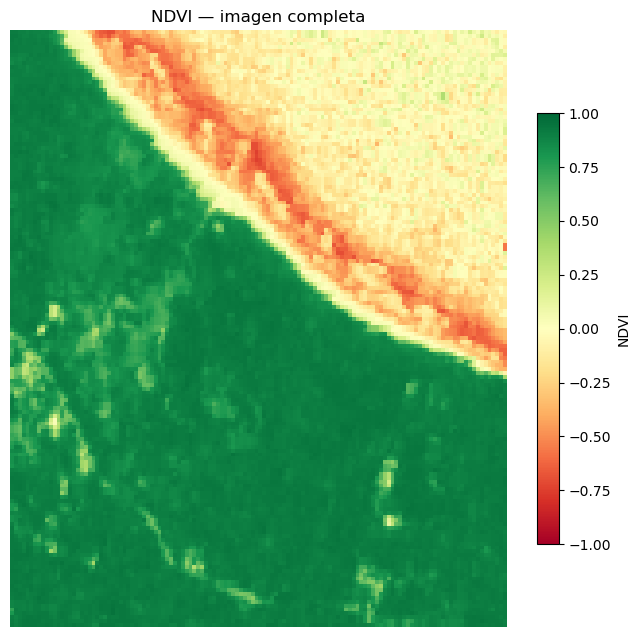

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(ndvi, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('NDVI — imagen completa')
ax.axis('off')
fig.colorbar(im, ax=ax, label='NDVI', shrink=0.7)
plt.show()

### Clasificación del NDVI por cobertura

Los valores de NDVI se asignan a una de cuatro categorías de cobertura. Los umbrales son una convención común pero pueden ajustarse según el contexto. La clasificación se aplica a **toda la imagen** y luego se sobrepone el polígono del refugio como referencia espacial.

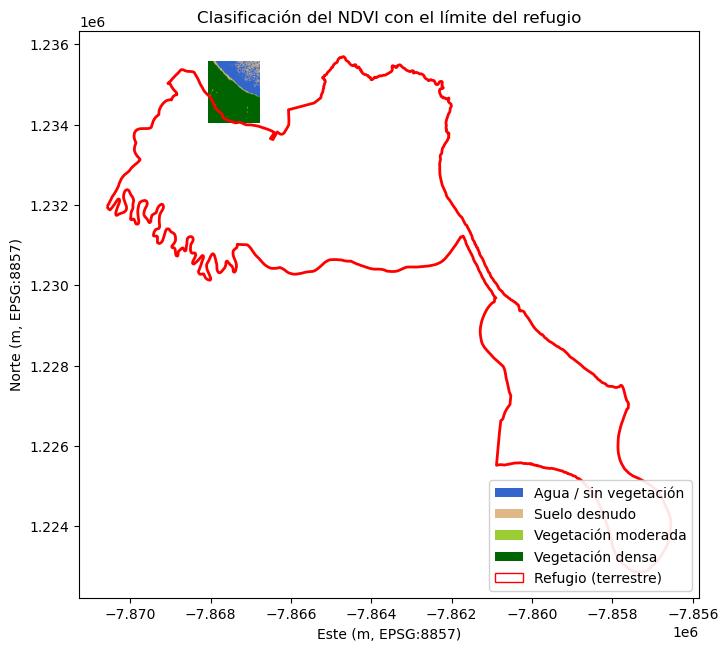

In [10]:
# Umbrales y etiquetas de las categorías
umbrales = [-1, 0, 0.2, 0.5, 1]
etiquetas = [
    'Agua / sin vegetación',
    'Suelo desnudo',
    'Vegetación moderada',
    'Vegetación densa',
]

# Asignar a cada píxel su categoría (1, 2, 3 o 4)
clases = np.digitize(ndvi, bins=umbrales[1:-1]) + 1

# Paleta categórica
colores = ['#3366cc', '#deb887', '#9acd32', '#006400']
cmap = ListedColormap(colores)
norm = BoundaryNorm([1, 2, 3, 4, 5], cmap.N)

# Extensión geográfica del raster, en su CRS, para alinear el polígono
extent = [
    imagen.bounds.left, imagen.bounds.right,
    imagen.bounds.bottom, imagen.bounds.top,
]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(clases, cmap=cmap, norm=norm, extent=extent)

# Sobreponer el polígono del refugio
refugio_8857_gdf.boundary.plot(
    ax=ax, color='red', linewidth=2,
)

ax.set_title('Clasificación del NDVI con el límite del refugio')
ax.set_xlabel('Este (m, EPSG:8857)')
ax.set_ylabel('Norte (m, EPSG:8857)')

# Leyenda
from matplotlib.patches import Patch
handles = [
    Patch(facecolor=colores[i], label=etiquetas[i]) for i in range(4)
]
handles.append(
    Patch(facecolor='none', edgecolor='red', label='Refugio (terrestre)')
)
ax.legend(handles=handles, loc='lower right', framealpha=0.9)
plt.show()

### Estadísticas zonales: imagen completa vs refugio

Para resumir el NDVI por categoría se comparan dos zonas: **toda la imagen** y **solo el área dentro del polígono del refugio**. La resolución de la imagen es de 10 m por píxel, así que cada píxel representa $10 \times 10 = 100 \text{ m}^2 = 0.01 \text{ ha}$. El área de cada categoría se obtiene multiplicando el conteo de píxeles por 100 m².

Para identificar los píxeles dentro del refugio se construye una máscara booleana del mismo tamaño que el raster con `rasterio.features.geometry_mask()`: el resultado es `True` en los píxeles que están dentro del polígono y `False` en los que están fuera.

In [11]:
# Máscara booleana: True donde está dentro del refugio
dentro_refugio = geometry_mask(
    refugio_8857_gdf.geometry,
    transform=imagen.transform,
    out_shape=ndvi.shape,
    invert=True,  # invertir: True dentro, False fuera
)

# Resolución del raster
res_x, res_y = imagen.res
area_pixel_m2 = res_x * res_y


def resumir(clases_zona: np.ndarray, etiqueta_zona: str) -> pd.DataFrame:
    valores, conteos = np.unique(clases_zona, return_counts=True)
    return pd.DataFrame({
        'zona': etiqueta_zona,
        'categoría': [etiquetas[v - 1] for v in valores],
        'píxeles': conteos,
        'área (ha)': conteos * area_pixel_m2 / 10_000,
        'porcentaje': 100 * conteos / conteos.sum(),
    })


# Estadísticas para la imagen completa
resumen_total = resumir(clases, 'Imagen completa')

# Estadísticas dentro del refugio
resumen_refugio = resumir(clases[dentro_refugio], 'Dentro del refugio')

# Tabla combinada
resumen = pd.concat([resumen_total, resumen_refugio], ignore_index=True)
resumen

,zona,categoría,píxeles,área (ha),porcentaje
0,Imagen completa,Agua / sin vegetación,4841,48.41,24.558644
1,Imagen completa,Suelo desnudo,1366,13.66,6.929789
2,Imagen completa,Vegetación moderada,218,2.18,1.105925
3,Imagen completa,Vegetación densa,13287,132.87,67.405641
4,Dentro del refugio,Suelo desnudo,2,0.02,0.114548
5,Dentro del refugio,Vegetación moderada,13,0.13,0.744559
6,Dentro del refugio,Vegetación densa,1731,17.31,99.140893


Más allá de la clasificación discreta, se pueden comparar también los valores **continuos** de NDVI en ambas zonas.

In [12]:
stats_ndvi = pd.DataFrame({
    'zona': ['Imagen completa', 'Dentro del refugio'],
    'píxeles': [ndvi.size, int(dentro_refugio.sum())],
    'NDVI mín': [np.nanmin(ndvi), np.nanmin(ndvi[dentro_refugio])],
    'NDVI máx': [np.nanmax(ndvi), np.nanmax(ndvi[dentro_refugio])],
    'NDVI medio': [np.nanmean(ndvi), np.nanmean(ndvi[dentro_refugio])],
    'NDVI mediana': [
        np.nanmedian(ndvi), np.nanmedian(ndvi[dentro_refugio])
    ],
})
stats_ndvi

,zona,píxeles,NDVI mín,NDVI máx,NDVI medio,NDVI mediana
0,Imagen completa,19712,-0.748175,0.951031,0.540783,0.869028
1,Dentro del refugio,1746,0.161318,0.948395,0.875717,0.901677


## Ejercicios

1. Aplique el mismo análisis a otra área silvestre protegida del Caribe (por ejemplo, el Parque Nacional Cahuita). ¿Necesita una imagen satelital distinta? ¿Por qué?

2. Cambie los umbrales de la clasificación del NDVI (por ejemplo, use 5 categorías en lugar de 4) y compare la distribución resultante. ¿Qué efecto tienen los umbrales sobre las conclusiones?